# Tutorial 5: Branching and Crosslinking Polymers
### Learning Objectives
* Generating specific branching
* Random branching
* 2-site crosslinking
* 3-site crosslinking
### Key Points
* 

## Setup
------

In [1]:
# Import necessary libraries
import mbuild as mb
from mbuild.path.termination import NumSites, Termination, WallTime
from mbuild.path.constraints import CuboidConstraint
from mbuild.path.build import Path, hard_sphere_random_walk, crosslink

import numpy as np
# Check mBuild version
print(f"mBuild version: {mb.__version__}")

mBuild version: 1.3.1


### Pattern crosslinking
-----


In [ ]:
# Create Polymer

# Add monomer with branch

# Add monomer without branch

# Build with pattern

# Visualize

## Random branching
--------

In [ ]:
# Create Polymer

# Add monomer with branch tag

# Build backbone

# Build branches

## 2-Site Crosslinking
-----

In [3]:
# Define system
bond_length = 0.15 # nm
chain_length = 50 # 50 mer
n_chains = 50
path = Path()

# Create finish criteria
num_sites = NumSites(chain_length)
walltime = WallTime(20)
conditions = Termination((num_sites, walltime))
constraint = CuboidConstraint(3,3,3, (False, False, False))

import time
start = time.time()
for step in range(n_chains): # create 25 chains
    # Build backbone chains
    hard_sphere_random_walk(
        path,
        radius=bond_length*0.95,
        bond_length=bond_length,
        termination=conditions,
        volume_constraint=constraint,
        rw_angles=(np.pi/2, np.pi)
    )
    # Perform Crosslinking
    if not (step+1) % 4: # every 4 steps, form crosslinks
        for i in range(10):
            try:
                crosslink(path, radius=0.5)
            except:
                pass
        # path.relax(bead_radius=bond_length*0.95, bond_length=bond_length, steps=1000)
print(f"Took {time.time()-start:.1f}s to generate {len(path.coordinates)} points")

# Visualize
path.visualize(radius=0.14)

Took 81.5s to generate 2523 points


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
from mbuild.path.build import Path, hard_sphere_random_walk, crosslink
from mbuild.path.termination import NumSites, Termination, WallTime
from mbuild.path.constraints import CuboidConstraint
import numpy as np

# Define system
bond_length = 0.15 # nm
chain_length = 50 # 50 mer
path = Path()

# Create finish criteria
num_sites = NumSites(chain_length)
walltime = WallTime(20)
conditions = Termination((num_sites, walltime))
constraint = CuboidConstraint(3,3,3, (False, False, False))

import time
start = time.time()
for step in range(40): # create 40 chains
    # Build backbone chains
    init_points = constraint.find_low_density_points(path.coordinates, 100, buffer=0.1)
    if not len(path.coordinates) % 500 and len(path.coordinates):
        print(f"{len(path.coordinates)//chain_length} Chains Added.")
    for init_point in init_points:
        try:
            hard_sphere_random_walk( # TODO: hsrw cuts off some chains early
                path,
                radius=bond_length*0.95,
                bond_length=bond_length,
                termination=conditions,
                initial_point=init_point,
                volume_constraint=constraint,
                rw_angles=(np.pi/2, np.pi),
                seed=10
            )
            break
        except:
            pass
for i in range(20):
    crosslink(path, radius=0.2, excluded_bond_depth=25, seed=10) 

print(f"Took {time.time()-start:.1f}s to generate {len(path.coordinates)} points")
clinks = sum([b == "_R" for b in path.beads])
bbones = sum([b == "_A" for b in path.beads])
print(f"{clinks} Crosslinks")
print(f"{bbones} Backbones")
print(f"{clinks*2/bbones*100:.1f}% clinks")

# Visualize
path.visualize()

10 Chains Added.
Took 60.8s to generate 1935 points
20 Crosslinks
1915 Backbones
2.1% clinks


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
from mbuild.path.build import Path, hard_sphere_random_walk, crosslink
from mbuild.path.termination import NumSites, Termination, WallTime
from mbuild.path.constraints import CuboidConstraint
# from mbuild.path.system_builder import crosslink_path

import numpy as np
import unyt as u

# Define system
bond_length = 0.15 # nm
chain_length = 100 # 50 mer
n_polymers = 20
n_crosslinks = 100
density = 0.8 * u.Unit("g/cm**3")
bead_mass = 14 * u.amu

# Setup objects
path = Path()
num_sites = NumSites(chain_length)
walltime = WallTime(30)
# conditions = Termination((num_sites, walltime))
conditions = Termination((num_sites))
box_length = (((chain_length*n_polymers + n_crosslinks)*bead_mass / density).in_units("nm**3").value )**(1/3)
constraint = CuboidConstraint(box_length, pbc=(True, True, True))
print(f"Box is {box_length} nm")

import time
start = time.time()
for step in range(n_polymers): # create 50 chains
    hard_sphere_random_walk( # TODO: hsrw cuts off some chains early, default tries a new hsrw custom mBuild error that we can catch with try except
        
        path,
        radius=bond_length*0.95,
        bond_length=bond_length,
        termination=conditions,
        volume_constraint=constraint,
        rw_angles=(np.pi/2, np.pi),
        seed=10 # TODO: seed None should create a random point
    )
for i in range(n_crosslinks):
    crosslink(path, radius=0.2, excluded_bond_depth=25, seed=10)  # This needs to have an associated state that determines if crosslinking has peaked

print(f"Took {time.time()-start:.1f}s to generate {len(path.coordinates)} points")
clinks = sum([b == "_R" for b in path.beads])
bbones = sum([b == "_A" for b in path.beads])
print(f"{clinks} Crosslinks")
print(f"{bbones} Backbones")
print(f"{clinks*2/bbones*100:.1f}% clinks")

Box is 3.9370306964618393 nm
Took 0.2s to generate 2100 points
100 Crosslinks
2000 Backbones
10.0% clinks


In [7]:
path.visualize()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

40


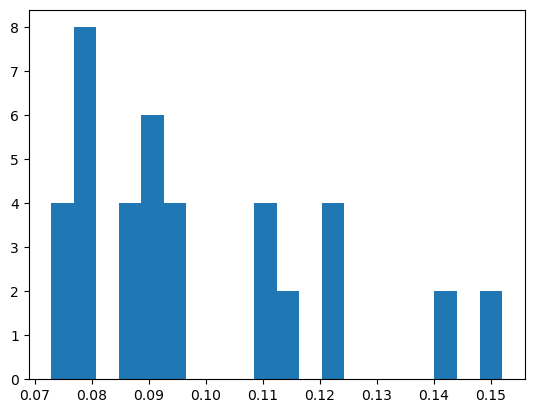

In [2]:
distances = []
backbone_nodes = [
    node for node, attrs in path.bond_graph.nodes(data=True)
    if (
        attrs.get("name") == "_A"
    )
]
bg = path.bond_graph
for node1, node2 in bg.edges:
    if path.beads[node1] == "_A" and path.beads[node2] == "_A":
        continue
    distances.append(bg.nodes[node1]['xyz'] - bg.nodes[node2]['xyz'])

lengths = np.linalg.norm(distances, axis=1)
import matplotlib.pyplot as plt
plt.hist(lengths, bins=20)
print(len(lengths))

In [3]:
# try to run a quick simulation
path.relax(bead_radius=0.1, bond_length=0.15) # TODO: on fail this should not update path coordinates to nan
cpd = path.to_compound()
print(len(cpd.check_for_overlap(1)), " overlaps found")
path.visualize()

2  overlaps found


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [17]:
from mbuild.path.build import Path, hard_sphere_random_walk, crosslink
from mbuild.path.termination import NumSites, Termination, WallTime
from mbuild.path.constraints import CuboidConstraint
import numpy as np

# Define system
bond_length = 0.15 # nm
chain_length = 50 # 50 mer
path = Path()

# Create finish criteria
num_sites = NumSites(chain_length)
walltime = WallTime(20)
conditions = Termination((num_sites, walltime))
constraint = CuboidConstraint(5,5,5)

for i in range(4):
    hard_sphere_random_walk(
        path,
        radius=bond_length*0.95,
        bond_length=bond_length,
        termination=conditions,
        initial_point=None, # TODO: add in crosslink atoms too
        volume_constraint=constraint,
        rw_angles=(np.pi/2, np.pi)
    )

crosslink(path, radius=bond_length)


# Visualize
path.visualize()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
path.relax(bead_radius=0.14, bond_length=0.15)
path.visualize()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

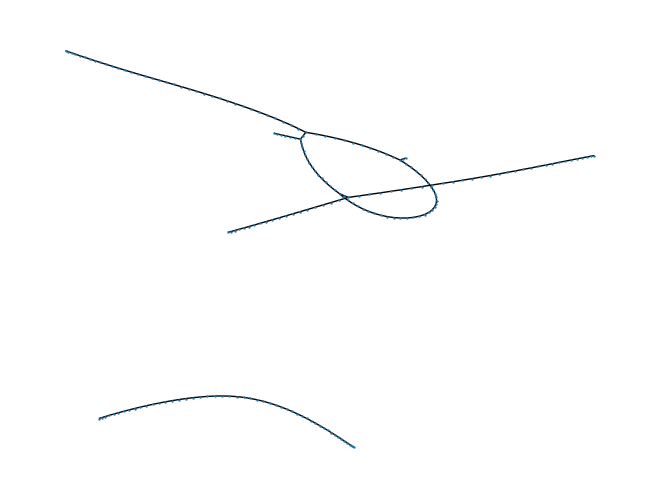

In [2]:
# path.bond_graph.nodes[4], path.bond_graph.nodes[50]
import networkx as nx
import matplotlib.pyplot as plt

pos = nx.spring_layout(path.bond_graph, k=0.1, iterations=5000)
nx.draw(path.bond_graph, pos, node_size=0.5)
plt.show()

In [12]:
path.bond_graph.edges(100)

EdgeDataView([(100, 8), (100, 6)])

## 3-site crosslinking
-----

In [ ]:
# Create backbone

# Create 3-site crosslinker

# Initialize build criteria

# Log steps to file

# Build and time

# View logs

### Exercise: 